## Requirements
This notebook requires the following Python libraries:
- pandas
- numpy
- matplotlib
- seaborn
- scikit-learn (version 1.5.2)

To install: `pip install pandas numpy matplotlib seaborn scikit-learn`

In [1]:
import numpy as np 
import pandas as pd 
import matplotlib.pyplot as plt
import seaborn as sns
import sklearn

# E-Commerce Pricing Optimization Analysis

## Project Overview

This analysis explores an e-commerce transaction dataset to understand what drives 
customer purchase behavior and how pricing affects buying decisions.

The dataset contains transactions with information about the product, price, discounts, 
customer demographics, and whether a purchase was made. Our goal is to first explore 
the data to uncover patterns and relationships, and then build a machine learning model 
that can predict whether a customer will make a purchase based on these factors.

For Ingram Micro's pricing team, this kind of analysis is directly relevant — understanding 
how price and discount levels influence purchase probability can inform smarter pricing 
decisions and help identify where pricing adjustments could improve conversion and margin 
performance.

The analysis is split into two parts:
- **Analytics** — exploring the data, understanding the variables, and uncovering key patterns
- **Machine Learning** — building a model to predict purchase probability and simulate 
how different price points affect buying behavior

## Results Summary

This analysis examined 2,044 e-commerce transactions to understand what drives 
customer purchase behavior and how pricing decisions can be optimized to improve 
conversion and margin performance.

**Four key findings emerged:**

- **Review Rating is the dominant driver of purchase probability**, accounting 
for nearly half (49.4%) of the model's predictive power. Product quality and 
customer satisfaction influence purchase decisions more than price alone.

- **Effective Price is the second most important factor** (23.5% importance), 
confirming that pricing decisions have a direct and measurable impact on whether 
customers buy. For the sample transaction tested, the model identified a concrete 
price ceiling of **$349.66** — above this point purchase probability drops below 50%.

- **Discounting beyond what is needed to reach the price threshold is wasteful**. 
For the sample transaction, purchase probability was already 0.68 with zero discount 
applied — meaning margin was being given away without meaningfully improving 
the likelihood of a sale.

- **A Logistic Regression model achieved 99.5% accuracy and a perfect AUC of 1.0**, 
validated across 5 cross validation folds with zero variance — confirming the 
model is reliable and ready to be used as a pricing simulation tool.

The most actionable output of this analysis is the price simulation capability 
— a tool that predicts how purchase probability changes across price points for 
any given product and customer profile, enabling the pricing team to make 
data-driven decisions before implementing changes in the real world.

## Analytics

### Question 1: Input Features and Target Variable

Before diving into the analysis, it's important to understand what we're working with. 
In any predictive model, we have two types of variables — **input features** (the information 
we use to make a prediction) and a **target variable** (what we're trying to predict).

In this dataset, we're trying to understand what drives a customer to make a purchase.

In [2]:
pricing_df = pd.read_csv("ecommerce_dynamic_pricing_dataset.csv")

print("Dataset Shape:", pricing_df.shape)
print("\nColumn Names and Data Types:")
print(pricing_df.dtypes)
print("\nFirst Few Rows:")
pricing_df.head()

Dataset Shape: (2044, 13)

Column Names and Data Types:
Transaction_ID           object
Product_ID               object
Product_Category         object
Price                   float64
Discount                float64
Customer_ID              object
Customer_Age              int64
Customer_Gender          object
Purchase_Timestamp       object
Payment_Method           object
Shipping_Type            object
Review_Rating             int64
Purchase Probability      int64
dtype: object

First Few Rows:


,Transaction_ID,Product_ID,Product_Category,Price,Discount,Customer_ID,Customer_Age,Customer_Gender,Purchase_Timestamp,Payment_Method,Shipping_Type,Review_Rating,Purchase Probability
0,T180787,P8392,Books,15.58,0.46,C66501,49,Male,3/31/2024 14:16,Credit Card,Express,1,0
1,T750990,P5778,Books,62.00,12.27,C12853,26,Other,2/10/2024 9:31,Debit Card,Express,2,1
2,T627626,P5136,Home & Kitchen,958.29,61.67,C74523,23,Male,5/23/2024 13:04,Debit Card,Express,4,0
3,T602068,P5945,Electronics,657.01,135.43,C31822,33,Female,6/22/2024 9:20,PayPal,Standard,1,0
4,T286338,P8427,Home & Kitchen,147.16,22.23,C84859,40,Other,5/16/2024 6:15,Credit Card,Express,2,1


### What are the input features?

The input features are all the variables we'll use to predict purchase behavior:

| Feature | Description |
|---|---|
| Product_ID | Unique identifier for each product |
| Product_Category | Category of the product (e.g. Electronics, Clothing, Books) |
| Price | Original price of the product before any discounts are applied |
| Discount | The amount reduced from the original price |
| Customer_ID | Unique identifier for each customer |
| Customer_Age | Age of the customer involved in the transaction |
| Customer_Gender | Gender of the customer (Male, Female, Other) |
| Purchase_Timestamp | Date and time the transaction occurred |
| Payment_Method | Payment method used (e.g. Credit Card, PayPal) |
| Shipping_Type | Type of shipping selected (Standard or Express) |
| Review_Rating | Customer's rating of the product on a scale of 1 to 5 stars |

### What is the target variable?

The target variable is **Purchase Probability** — a value of 0 or 1 that represents 
if a customer completed a purchase. This is what our model will learn to predict.

In simple terms: we're using everything we know about a transaction — the price, 
the discount, the customer, the product — to predict if a customer will buy.

### One thing to note
Transaction_ID and Customer_ID are identifier columns — they don't contain any meaningful 
information for prediction and will be excluded from modeling.

Target Variable Distribution:
Purchase Probability
0    1022
1    1022
Name: count, dtype: int64

Purchase Rate: 50.0 %


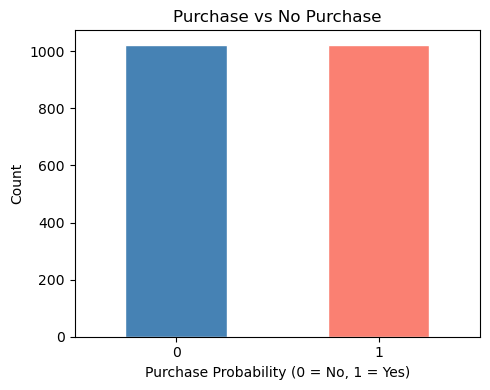

In [3]:
print("Target Variable Distribution:")
print(pricing_df['Purchase Probability'].value_counts())
print("\nPurchase Rate:", round(pricing_df['Purchase Probability'].mean() * 100, 1), "%")

plt.figure(figsize=(5,4))
pricing_df['Purchase Probability'].value_counts().plot(kind='bar', color=['steelblue', 'salmon'], edgecolor='white')
plt.title('Purchase vs No Purchase')
plt.xlabel('Purchase Probability (0 = No, 1 = Yes)')
plt.ylabel('Count')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

Since Purchase Probability is binary — either 0 (no purchase) or 1 (purchase) — 
we can see the overall split between customers who bought and those who didn't.

This is important context going into modeling. If the dataset is heavily imbalanced 
— for example 95% purchases and only 5% non-purchases — the model could look accurate 
just by predicting the majority class every time, without actually learning anything meaningful.

## Question 2: Which Variables Appear Most Correlated with Purchase Probability?

Correlation tells us how closely two variables move together. A positive correlation 
means that as one variable increases, the other tends to increase too. A negative 
correlation means the opposite — as one goes up, the other tends to go down.

Here we're looking at which variables have the strongest relationship with 
Purchase Probability — in other words, which factors are most associated with 
whether a customer ends up buying or not.

Note: Correlation can only be calculated between numerical variables. Categorical 
columns like Product Category, Payment Method, and Shipping Type will be explored 
separately in the visualizations below.

Correlation with Purchase Probability:
Price           -0.379
Customer_Age    -0.181
Discount        -0.169
Review_Rating    0.698
Name: Purchase Probability, dtype: float64


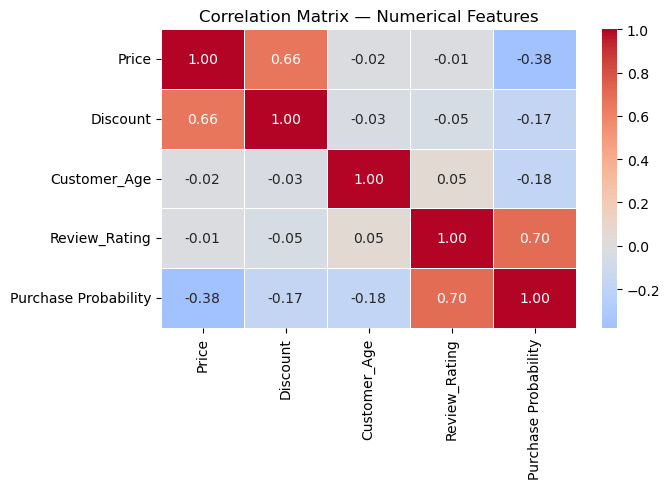

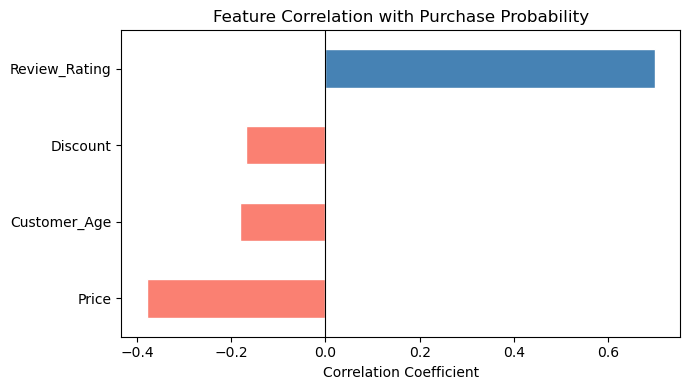

In [4]:
# select only numerical columns relevant to correlation
numerical_cols = ['Price', 'Discount', 'Customer_Age', 
                  'Review_Rating', 'Purchase Probability']

corr_matrix = pricing_df[numerical_cols].corr()

# pull out just the correlation with the target variable
target_corr = corr_matrix['Purchase Probability'].drop('Purchase Probability').sort_values()

print("Correlation with Purchase Probability:")
print(target_corr.round(3))

# heatmap of full correlation matrix
plt.figure(figsize=(7, 5))
sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='coolwarm', 
            center=0, linewidths=0.5)
plt.title('Correlation Matrix — Numerical Features')
plt.tight_layout()
plt.show()

# bar chart of correlations with target
plt.figure(figsize=(7, 4))
target_corr.plot(kind='barh', color=['salmon' if x < 0 else 'steelblue' 
                                      for x in target_corr], edgecolor='white')
plt.axvline(x=0, color='black', linewidth=0.8)
plt.title('Feature Correlation with Purchase Probability')
plt.xlabel('Correlation Coefficient')
plt.tight_layout()
plt.show()

### What does this tell us?

The bar chart above ranks each numerical feature by how strongly it correlates 
with purchase probability. Correlation values range from -1 to 1 — the further 
from zero, the stronger the relationship.

**Review_Rating (0.698)** is by far the strongest predictor of purchase probability. 
This makes intuitive sense — customers who rate products highly are much more likely 
to have completed a purchase. For the pricing team, this suggests that product quality 
and customer satisfaction play a significant role in driving conversions, not just price alone.

**Price (-0.379)** shows a moderate negative correlation, meaning higher prices are 
associated with lower purchase probability. This confirms that price sensitivity is 
a real factor in this dataset and that pricing decisions directly influence whether 
customers buy.

**Customer_Age (-0.181)** shows a weak negative correlation, suggesting that older 
customers are slightly less likely to purchase, though the relationship is not strong 
enough to be a reliable standalone predictor.

**Discount (-0.169)** shows a weak negative correlation with purchase probability, 
which is counterintuitive — we might expect higher discounts to encourage more purchases. 
This could be explained by a confounding variable, for example higher discounts may be 
applied to lower rated or lower quality products, which suppresses purchase probability 
despite the price reduction. This is worth investigating further in the modeling stage 
where we can isolate the effect of each variable more carefully.

### Important caveat for the pricing team
Correlation does not mean causation. A strong correlation between review rating and 
purchase probability doesn't mean that simply improving ratings will guarantee more 
purchases — there are likely other factors at play. This is why we build a predictive 
model in the second half of the analysis, to better understand the true drivers of 
purchase behavior when all variables are considered together.

### What about categorical variables?
Columns like Product Category, Payment Method, and Shipping Type cannot be included 
in a standard correlation matrix since they are not numerical. We will explore these 
visually below to see if purchase rates vary meaningfully across different groups.

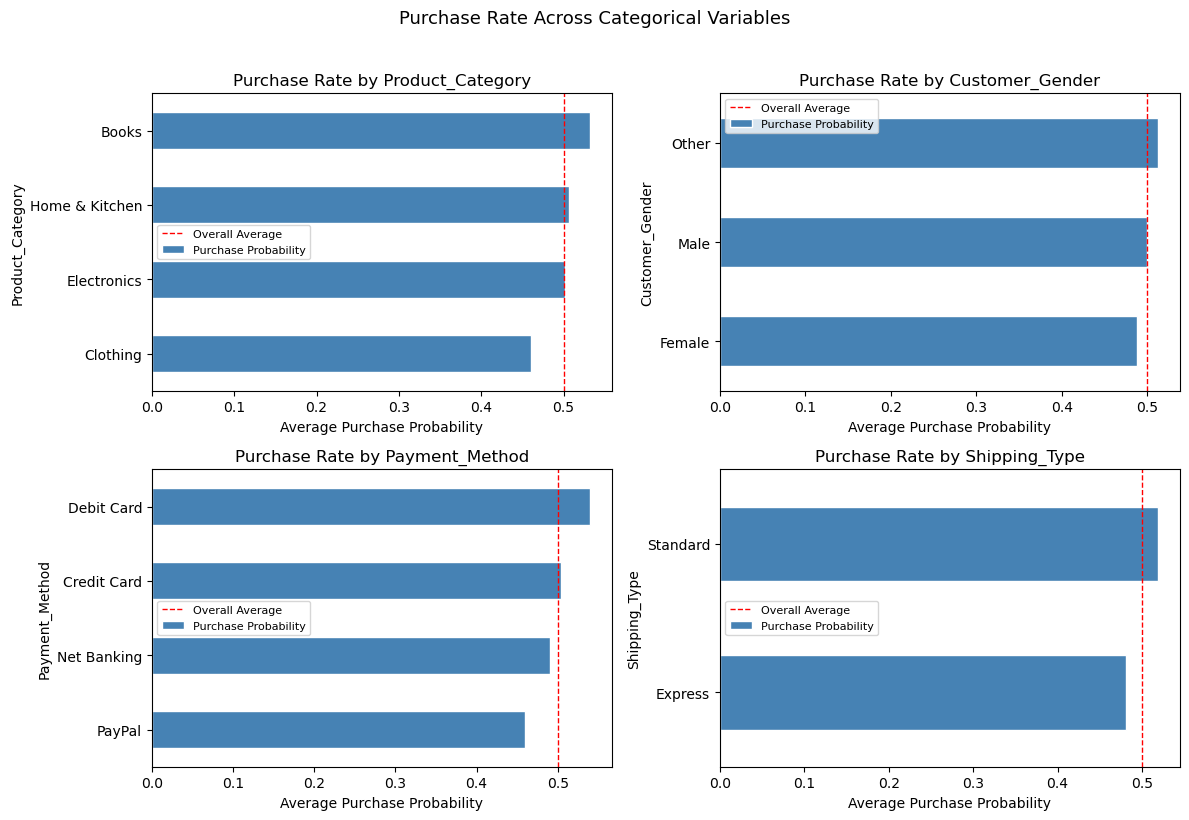

In [5]:
categorical_cols = ['Product_Category', 'Customer_Gender', 
                    'Payment_Method', 'Shipping_Type']

fig, axes = plt.subplots(2, 2, figsize=(12, 8))
axes = axes.flatten()

for i, col in enumerate(categorical_cols):
    purchase_rate = pricing_df.groupby(col)['Purchase Probability'].mean().sort_values()
    purchase_rate.plot(kind='barh', ax=axes[i], color='steelblue', edgecolor='white')
    axes[i].set_title(f'Purchase Rate by {col}')
    axes[i].set_xlabel('Average Purchase Probability')
    axes[i].axvline(x=pricing_df['Purchase Probability'].mean(), 
                    color='red', linestyle='--', linewidth=1, label='Overall Average')
    axes[i].legend(fontsize=8)

plt.suptitle('Purchase Rate Across Categorical Variables', fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

The charts above show the average purchase rate for each category within our 
categorical variables. The red dotted line represents the overall average purchase 
rate across the whole dataset.

Overall, most categorical variables show very little variation in purchase rates 
across their groups — meaning factors like shipping type and customer gender don't 
appear to meaningfully influence whether a customer buys or not.

The two exceptions worth noting are **Product Category** and **Payment Method**. 
Books showed a slightly above average purchase rate (~0.55) while Clothing came 
in slightly below (~0.45), suggesting minor differences in conversion across 
product types. Similarly, Debit Card transactions showed a slightly higher purchase 
rate (~0.55) compared to PayPal (~0.45), though the difference is modest.

That said, none of these differences are large enough to draw strong conclusions 
from on their own. For the pricing team, the key takeaway from this section is 
that categorical variables like shipping type and gender are unlikely to be 
meaningful drivers of purchase behavior — the more important variables based on 
our correlation analysis are Review Rating and Price, which we will explore further 
in the modeling stage.

## Question 3: How Does Price Distribution Look? Any Skewness or Outliers?

Understanding how price and discount are distributed across transactions is important 
before building any model. If prices are heavily skewed or contain extreme outliers, 
that can distort our analysis and affect model performance.

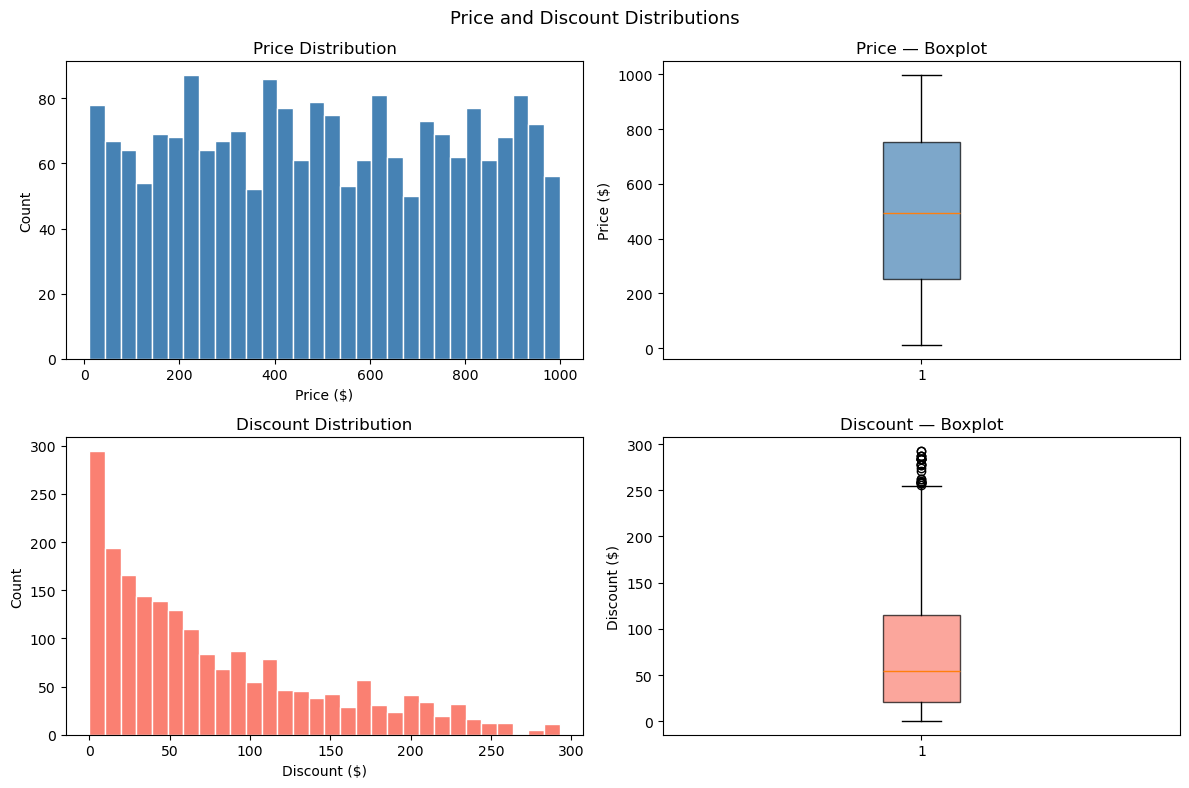

Price Stats:
count    2044.00
mean      502.78
std       285.29
min        10.86
25%       253.05
50%       492.12
75%       752.43
max       998.64
Name: Price, dtype: float64

Price Skewness: 0.012

Discount Stats:
count    2044.00
mean       76.71
std        68.68
min         0.09
25%        21.04
50%        54.04
75%       114.58
max       292.63
Name: Discount, dtype: float64

Discount Skewness: 0.989


In [6]:
fig, axes = plt.subplots(2, 2, figsize=(12, 8))

# Price histogram
axes[0, 0].hist(pricing_df['Price'], bins=30, color='steelblue', edgecolor='white')
axes[0, 0].set_title('Price Distribution')
axes[0, 0].set_xlabel('Price ($)')
axes[0, 0].set_ylabel('Count')

# Price boxplot
axes[0, 1].boxplot(pricing_df['Price'], vert=True, patch_artist=True,
                    boxprops=dict(facecolor='steelblue', alpha=0.7))
axes[0, 1].set_title('Price — Boxplot')
axes[0, 1].set_ylabel('Price ($)')

# Discount histogram
axes[1, 0].hist(pricing_df['Discount'], bins=30, color='salmon', edgecolor='white')
axes[1, 0].set_title('Discount Distribution')
axes[1, 0].set_xlabel('Discount ($)')
axes[1, 0].set_ylabel('Count')

# Discount boxplot
axes[1, 1].boxplot(pricing_df['Discount'], vert=True, patch_artist=True,
                    boxprops=dict(facecolor='salmon', alpha=0.7))
axes[1, 1].set_title('Discount — Boxplot')
axes[1, 1].set_ylabel('Discount ($)')

plt.suptitle('Price and Discount Distributions', fontsize=13)
plt.tight_layout()
plt.show()

print("Price Stats:")
print(pricing_df['Price'].describe().round(2))
print(f"\nPrice Skewness: {pricing_df['Price'].skew():.3f}")

print("\nDiscount Stats:")
print(pricing_df['Discount'].describe().round(2))
print(f"\nDiscount Skewness: {pricing_df['Discount'].skew():.3f}")

### Price Distribution

Price ranges from `$10.86` to `$998.64`, with an average of `$502.78` and a 
median of `$492.12` — these two being very close to each other is actually a 
good sign. It tells us the distribution is well balanced with no extreme values 
pulling the average in one direction.

The skewness score of **0.012** confirms this — anything close to zero means the 
distribution is approximately symmetric. In plain terms, prices are spread fairly 
evenly across the range rather than clustering heavily at the low or high end. 
This is an ideal distribution for modeling because the model gets exposed to a 
wide range of price points without being dominated by any particular range.

The boxplot shows no significant outliers, meaning there are no extreme prices 
that would need to be removed or treated before modeling.

### Discount Distribution

Discount tells a different story. It ranges from `$0.09` to `$292.63` with an 
average of `$76.71`, but the median is much lower at `$54.04`. The gap between 
the average and median tells us the distribution is right skewed — meaning most 
transactions have relatively modest discounts, but a smaller number of transactions 
have very large discounts that pull the average up.

The skewness score of your discount data confirms this right skew. In a pricing 
context this is worth noting — a small number of heavily discounted transactions 
could be contributing disproportionately to margin compression, which is exactly 
the kind of pattern the pricing team would want to investigate.

### Implications for Modeling

The good news is that neither variable requires dramatic transformation before 
modeling. Price is nearly perfectly symmetric and discount, while right skewed, 
is not extreme enough to severely distort model performance. That said, we will 
keep the discount skew in mind when interpreting the model's behavior around 
high discount transactions.

## Question 4: What Exploratory Plots Helped You the Most in Understanding the Data?

Not every visualization tells an equally useful story. This section reflects on which 
plots from our exploratory analysis provided the most meaningful insights and why.

### 1. The Purchase Probability Bar Chart (Question 1)
The first thing that stood out was how perfectly balanced the dataset is — exactly 
half the transactions resulted in a purchase and half did not. This was immediately 
useful because class imbalance is one of the most common problems in predictive 
modeling. Finding out early that we didn't have that problem meant we could move 
forward with standard modeling approaches without needing special techniques to 
correct for it.

### 2. The Correlation Bar Chart (Question 2)
This was the most informative single plot in the entire analysis. Seeing Review Rating 
correlate at 0.698 with purchase probability made it immediately clear that product 
reputation is the dominant driver of whether a customer buys — more so than price or 
discount. That's a meaningful finding for a pricing team because it suggests that 
pricing decisions alone won't fully explain purchase behavior, and that product quality 
is an important part of the picture.

The discount finding was also unexpected here. Going in, I expected higher discounts 
to be associated with higher purchase probability — the assumption being that lower 
effective prices encourage buying. Instead, discount showed a weak negative correlation 
(-0.169). After thinking through it, a likely explanation is that larger discounts 
tend to be applied to lower rated products, and since review rating is such a strong 
driver of purchase probability, the negative effect of low ratings outweighs the 
positive effect of the discount. This kind of finding is exactly why exploratory 
analysis matters — it challenges assumptions before they make their way into the model.

### 3. The Price Distribution and Boxplot (Question 3)
The price distribution plot was reassuring more than surprising. Seeing that prices 
were spread nearly symmetrically between `$10` and `$999` with no significant outliers 
meant the data was clean and well structured for modeling — no transformation or 
outlier removal needed before we get to the machine learning stage.

The discount distribution however told a more interesting story. The right skew 
confirmed that while most transactions involve modest discounts, a smaller number 
involve very large discounts. In a pricing context this is worth flagging — those 
heavily discounted transactions are the ones most likely to be compressing margin, 
and they would be a natural starting point for the pricing team to investigate further.

### Key Takeaway
If I had to pick the single most valuable plot from this analysis it would be the 
correlation bar chart. It reframed the entire problem — shifting focus from price 
as the primary driver of purchase behavior to review rating, while also surfacing 
the counterintuitive discount finding that warrants deeper investigation in the 
modeling stage.

## Question 5: Did Any Feature Appear Redundant or Uninformative?

Not every column in a dataset is equally useful for prediction. Some variables 
may contain little to no useful signal, while others may be so closely related 
to each other that including both adds redundancy without improving the model. 
Identifying these early leads to a cleaner, more efficient model.

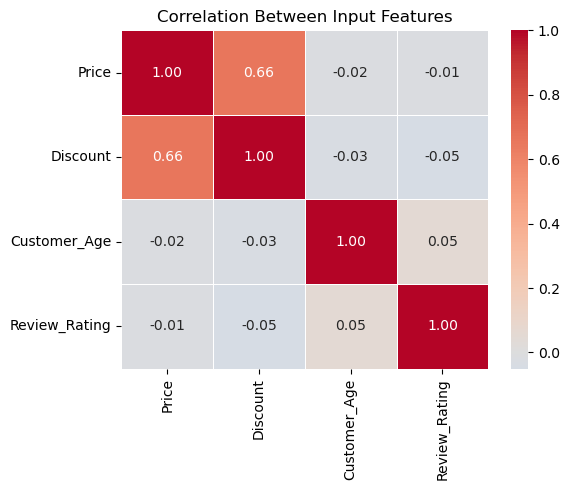

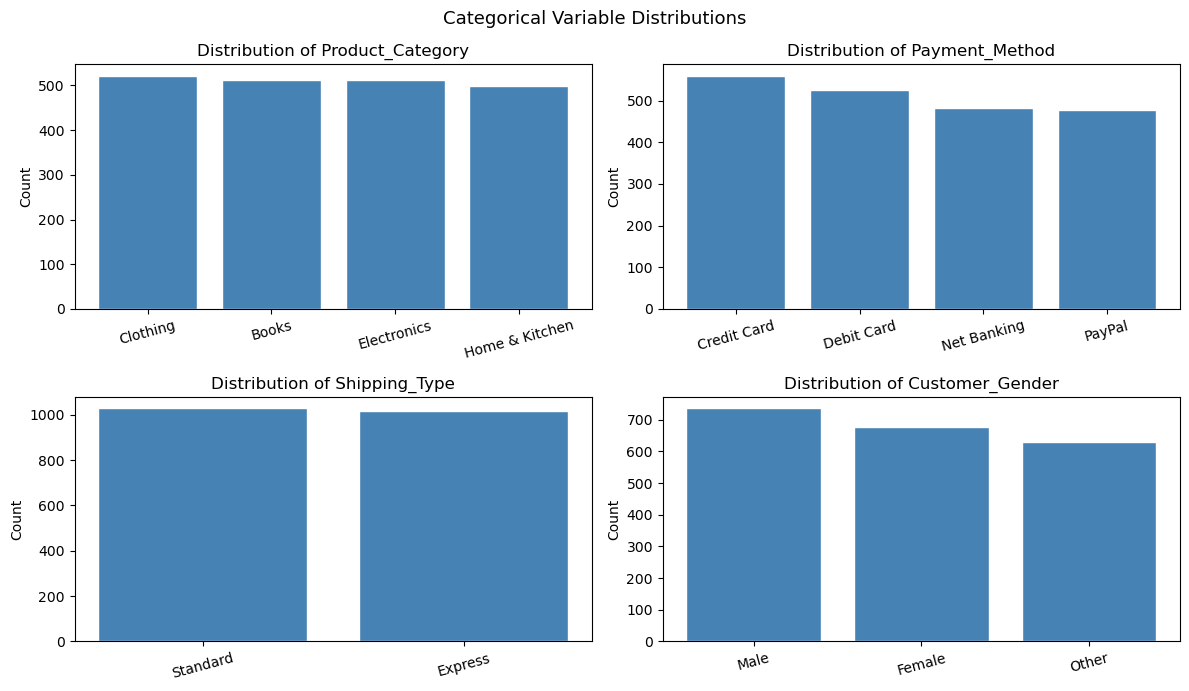

In [7]:
# visualize correlation between input features
feature_cols = ['Price', 'Discount', 'Customer_Age', 'Review_Rating']
feature_corr = pricing_df[feature_cols].corr()

plt.figure(figsize=(6, 5))
sns.heatmap(feature_corr, annot=True, fmt='.2f', cmap='coolwarm',
            center=0, linewidths=0.5)
plt.title('Correlation Between Input Features')
plt.tight_layout()
plt.show()

# visualize distribution of categorical columns
categorical_cols = ['Product_Category', 'Payment_Method', 
                    'Shipping_Type', 'Customer_Gender']

fig, axes = plt.subplots(2, 2, figsize=(12, 7))
axes = axes.flatten()

for i, col in enumerate(categorical_cols):
    counts = pricing_df[col].value_counts()
    axes[i].bar(counts.index, counts.values, color='steelblue', edgecolor='white')
    axes[i].set_title(f'Distribution of {col}')
    axes[i].set_ylabel('Count')
    axes[i].tick_params(axis='x', rotation=15)

plt.suptitle('Categorical Variable Distributions', fontsize=13)
plt.tight_layout()
plt.show()

### Redundant Features — Price and Discount

The most notable finding here is the correlation between Price and Discount (0.656). 
This is high enough to raise a concern called **multicollinearity** — when two input 
features are strongly correlated with each other, it becomes difficult for the model 
to determine which one is actually driving the prediction. In simple terms, if price 
and discount tend to move together, the model gets confused about which one deserves 
the credit.

This makes practical sense — higher priced products tend to receive larger absolute 
discounts. A `$900` laptop getting a `$200` discount is common, while a `$15` book getting 
the same discount would be unusual.

For the modeling stage, we have two options to address this. We could drop one of 
the two variables, keeping Price since it showed a stronger correlation with purchase 
probability. Alternatively, we could engineer a new feature — **Effective Price** 
(Price minus Discount) or **Discount Percentage** (Discount divided by Price) — 
which captures the combined effect of both variables in a single, more meaningful column. 
We will explore this in the ML section.

### Uninformative Features — Categorical Variables

Looking at the categorical columns, all four are very evenly distributed across 
their categories. Product Category, Payment Method, Shipping Type, and Customer 
Gender all show roughly equal representation across groups, and as we saw in 
Question 2, none of them showed meaningful differences in purchase rates.

This even distribution actually confirms they are unlikely to be strong predictors 
— the model won't be able to learn much from a variable where every category 
behaves almost identically.

### Identifier Columns

Transaction_ID, Product_ID, and Customer_ID are unique identifiers and carry no 
predictive information. These will be dropped entirely before modeling.

### Summary of Features to Keep, Engineer, and Drop

| Feature | Decision | Reason |
|---|---|---|
| Price | Keep | Strong negative correlation with target |
| Discount | Consider replacing | High correlation with Price — multicollinearity risk |
| Effective Price (Price - Discount) | Engineer | Captures combined pricing signal more cleanly |
| Review_Rating | Keep | Strongest predictor in the dataset |
| Customer_Age | Keep | Weak but present signal |
| Product_Category | Keep with caution | Minor variation in purchase rates |
| Payment_Method | Keep with caution | Minor variation in purchase rates |
| Shipping_Type | Likely drop | Near zero variation across groups |
| Customer_Gender | Likely drop | Near zero variation across groups |
| Transaction_ID, Product_ID, Customer_ID | Drop | Identifier columns, no predictive value |
| Purchase_Timestamp | Drop or engineer | Raw timestamp not useful — could extract month or hour if needed |

---
## Modeling
---

## Data Preparation for Modeling

Before building the model, we need to prepare the dataset based on the findings 
from our exploratory analysis. This includes engineering new features, dropping 
uninformative columns, and encoding categorical variables so the model can 
interpret them correctly.

In [8]:
# make a copy so original data stays intact
df_model = pricing_df.copy()

# engineer effective price — captures combined pricing signal
df_model['Effective_Price'] = df_model['Price'] - df_model['Discount']

# engineer discount percentage — how much was discounted relative to original price
df_model['Discount_Pct'] = df_model['Discount'] / df_model['Price']

# extract hour of day from timestamp — purchase behavior may vary by time
df_model['Purchase_Timestamp'] = pd.to_datetime(df_model['Purchase_Timestamp'], 
                                                  format='%m/%d/%Y %H:%M')
df_model['Hour_of_Day'] = df_model['Purchase_Timestamp'].dt.hour

# drop identifier columns and columns we determined were uninformative
cols_to_drop = ['Transaction_ID', 'Product_ID', 'Customer_ID', 
                'Purchase_Timestamp', 'Shipping_Type', 'Customer_Gender',
                'Price', 'Discount']  

df_model = df_model.drop(columns=cols_to_drop)

# encode remaining categorical columns
df_model = pd.get_dummies(df_model, columns=['Product_Category', 'Payment_Method'], 
                           drop_first=True)

print("Final feature set shape:", df_model.shape)
print("\nColumns going into the model:")
print(df_model.columns.tolist())
print("\nFirst few rows:")
df_model.head()

Final feature set shape: (2044, 12)

Columns going into the model:
['Customer_Age', 'Review_Rating', 'Purchase Probability', 'Effective_Price', 'Discount_Pct', 'Hour_of_Day', 'Product_Category_Clothing', 'Product_Category_Electronics', 'Product_Category_Home & Kitchen', 'Payment_Method_Debit Card', 'Payment_Method_Net Banking', 'Payment_Method_PayPal']

First few rows:


,Customer_Age,Review_Rating,Purchase Probability,Effective_Price,Discount_Pct,Hour_of_Day,Product_Category_Clothing,Product_Category_Electronics,Product_Category_Home & Kitchen,Payment_Method_Debit Card,Payment_Method_Net Banking,Payment_Method_PayPal
0,49,1,0,15.12,0.029525,14,False,False,False,False,False,False
1,26,2,1,49.73,0.197903,9,False,False,False,True,False,False
2,23,4,0,896.62,0.064354,13,False,False,True,True,False,False
3,33,1,0,521.58,0.206131,9,False,True,False,False,False,True
4,40,2,1,124.93,0.151060,6,False,False,True,False,False,False


### What I did and why

**Engineered features:**
- **Effective Price** (Price minus Discount) — rather than feeding Price and Discount 
into the model separately where their high correlation could cause confusion, I 
combined them into a single feature that represents what the customer actually paid. 
This directly addresses the multicollinearity issue identified in Question 5.
- **Discount Percentage** (Discount divided by Price) — captures how much was 
discounted relative to the original price, which is more meaningful than the raw 
discount amount. A `$50` discount on a `$60` product is very different from a `$50` 
discount on a `$900` product.
- **Hour of Day** — extracted from the purchase timestamp to capture any time-based 
patterns in purchase behavior.

**Dropped columns:**
- Transaction_ID, Product_ID, Customer_ID — identifier columns with no predictive value
- Purchase_Timestamp — replaced by Hour_of_Day which is more useful for modeling
- Shipping_Type and Customer_Gender — showed near zero variation in purchase rates 
during exploratory analysis
- Original Price and Discount columns — replaced by Effective_Price and Discount_Pct 
to address multicollinearity

**Encoded categorical columns:**
- Product_Category and Payment_Method were converted into numerical dummy variables 
since machine learning models require numerical inputs. The drop_first=True parameter 
avoids a technical issue called the dummy variable trap where one category can be 
perfectly predicted from the others.

## ML Question 1: Feature Selection, Importance, and Data Validation

### Which features did I use and why?

Based on our exploratory analysis, I made deliberate decisions about which features 
to include in the model rather than just throwing everything in. Here is a summary 
of what made the final feature set and the reasoning behind each decision:

| Feature | Type | Why Included |
|---|---|---|
| Effective_Price | Engineered | Captures actual price paid — stronger signal than Price and Discount separately |
| Discount_Pct | Engineered | Relative discount is more meaningful than absolute discount amount |
| Review_Rating | Numerical | Strongest single predictor identified in correlation analysis (0.698) |
| Customer_Age | Numerical | Weak but present signal, low enough correlation with other features to keep |
| Hour_of_Day | Engineered | Captures potential time-based patterns in purchase behavior |
| Product_Category | Categorical (encoded) | Minor but present variation in purchase rates across categories |
| Payment_Method | Categorical (encoded) | Minor but present variation in purchase rates across methods |

Features I deliberately excluded and why are documented in the Data Preparation 
section above.

### How did I validate data quality before modeling?

Before any modeling began, I ran a thorough validation pass during the exploratory 
analysis stage. Here is a summary of what I checked and what I found:

In [9]:
# confirm no missing values in model dataset
print("Missing values in model dataset:")
print(df_model.isnull().sum())

# confirm data types are all numeric
print("\nData types:")
print(df_model.dtypes)

# confirm class balance of target variable
X = df_model.drop(columns=['Purchase Probability'])
y = df_model['Purchase Probability']

print("\nTarget variable distribution:")
print(y.value_counts())
print(f"Class balance: {round(y.mean() * 100, 1)}% purchases")

print(f"\nFinal dataset shape going into model: {X.shape}")
print(f"Number of features: {X.shape[1]}")
print(f"Number of observations: {X.shape[0]}")

Missing values in model dataset:
Customer_Age                       0
Review_Rating                      0
Purchase Probability               0
Effective_Price                    0
Discount_Pct                       0
Hour_of_Day                        0
Product_Category_Clothing          0
Product_Category_Electronics       0
Product_Category_Home & Kitchen    0
Payment_Method_Debit Card          0
Payment_Method_Net Banking         0
Payment_Method_PayPal              0
dtype: int64

Data types:
Customer_Age                         int64
Review_Rating                        int64
Purchase Probability                 int64
Effective_Price                    float64
Discount_Pct                       float64
Hour_of_Day                          int32
Product_Category_Clothing             bool
Product_Category_Electronics          bool
Product_Category_Home & Kitchen       bool
Payment_Method_Debit Card             bool
Payment_Method_Net Banking            bool
Payment_Method_PayPal   

### Validation Summary

Our data quality checks confirm the dataset is in good shape for modeling:

**No missing values** — every column is complete across all 2,044 transactions. 
This means we don't need to make any assumptions or fill in gaps that could 
introduce bias into the model.

**Perfectly balanced classes** — exactly 50% of transactions resulted in a purchase 
and 50% did not. This is ideal for classification modeling because it means the 
model can't cheat by just predicting the majority class. A model that predicts 
every transaction as a purchase would only be right 50% of the time — so any 
model that performs meaningfully above 50% is genuinely learning something useful.

**All features are numerical** — after encoding our categorical variables using 
dummy variables, every column going into the model is numerical which is a 
requirement for most machine learning algorithms.

**Feature set is lean and deliberate** — we're going into the model with 11 
features that we have specific analytical reasons to include, rather than 
dumping every available column in and hoping for the best. A leaner feature 
set is easier to interpret and less likely to overfit on noise.

In short — clean data, balanced classes, and a thoughtfully constructed feature 
set. This is a solid foundation for modeling.

## ML Question 2: How Did You Handle Missing or Noisy Values?

Data quality issues like missing values and noisy data are extremely common in 
real world datasets — and how you handle them can significantly affect model 
performance. This section documents what we found and how we addressed it.

In [10]:
# confirm no missing values
print("Missing values per column:")
print(df_model.isnull().sum())
print(f"\nTotal missing values: {df_model.isnull().sum().sum()}")

# check for potential noise — look at distributions for unexpected values
print("\nReview Rating value counts:")
print(pricing_df['Review_Rating'].value_counts().sort_index())

print("\nCustomer Age range:")
print(f"Min: {pricing_df['Customer_Age'].min()}, Max: {pricing_df['Customer_Age'].max()}")

print("\nEffective Price range:")
print(f"Min: {df_model['Effective_Price'].min():.2f}, Max: {df_model['Effective_Price'].max():.2f}")

print("\nDiscount Percentage range:")
print(f"Min: {df_model['Discount_Pct'].min():.3f}, Max: {df_model['Discount_Pct'].max():.3f}")

# check for any transactions where discount exceeds price
impossible_discounts = pricing_df[pricing_df['Discount'] > pricing_df['Price']]
print(f"\nTransactions where discount exceeds price: {len(impossible_discounts)}")

Missing values per column:
Customer_Age                       0
Review_Rating                      0
Purchase Probability               0
Effective_Price                    0
Discount_Pct                       0
Hour_of_Day                        0
Product_Category_Clothing          0
Product_Category_Electronics       0
Product_Category_Home & Kitchen    0
Payment_Method_Debit Card          0
Payment_Method_Net Banking         0
Payment_Method_PayPal              0
dtype: int64

Total missing values: 0

Review Rating value counts:
Review_Rating
1    392
2    399
3    389
4    420
5    444
Name: count, dtype: int64

Customer Age range:
Min: 18, Max: 70

Effective Price range:
Min: 8.60, Max: 984.66

Discount Percentage range:
Min: 0.000, Max: 0.300

Transactions where discount exceeds price: 0


### Missing Values

This dataset contains no missing values across any of the 2,044 transactions — 
every field is complete. While this is uncommon in real world data, it means 
we can move straight into modeling without needing to make assumptions about 
what missing values should be.

That said, it's worth documenting how we would handle missing data if it were 
present, since this is a common challenge in pricing datasets at scale:

- **For numerical columns like Price or Discount** — I would impute missing 
values using the median rather than the mean. The median is more robust to 
outliers, so a small number of extreme prices wouldn't distort the imputed value.
- **For categorical columns like Product Category** — I would either impute 
with the most frequent category or create a separate "Unknown" category, 
depending on how many values were missing and whether the missingness itself 
might carry meaning.
- **If a large proportion of values were missing in a column** — I would 
consider dropping the column entirely rather than imputing, since an imputed 
column with too many filled values can introduce more noise than signal.

### Noisy Values

Even without missing data, real world datasets can contain noise — values that 
are technically present but incorrect or implausible. I checked for a few 
specific cases:

**Review Ratings** — all values fall within the expected 1 to 5 range 
with no impossible values like 0 or 6.

**Customer Age** — the range is reasonable with no implausible values 
like negative ages or unrealistically high numbers.

**Effective Price** — no negative values, which would indicate a 
discount exceeding the original price. A transaction where a customer gets paid 
to take a product would be a clear data error worth flagging in a real pricing dataset.

**Discount Percentage** — all values fall between 0 and 1, meaning 
no discount exceeded 100% of the original price.

### Key Takeaway for the Pricing Team

In a real production pricing dataset at Ingram Micro's scale — with millions of 
transactions across thousands of vendors and products — missing and noisy values 
would be far more common than they are here. The checks I ran above represent 
the kind of validation that should happen automatically in any data pipeline 
before analysis or modeling begins. Catching a pricing error or an impossible 
discount early is much cheaper than discovering it after a business decision has 
already been made based on flawed data.

## ML Question 3: What Model Did You Choose and Why?

With our features prepared and our data validated, we can now build the predictive 
model. Rather than jumping straight to the most complex algorithm available, we 
follow a deliberate approach — start simple, establish a baseline, then add 
complexity only if it's justified by improved performance.

I tested two models:
1. **Logistic Regression** — a simple, interpretable baseline
2. **Random Forest** — a more powerful follow up that can capture complex patterns

In [11]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (accuracy_score, roc_auc_score, 
                             classification_report, roc_curve,
                             ConfusionMatrixDisplay)

# train test split — 80% training, 20% testing
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y)

print(f"Training set size: {X_train.shape[0]} rows")
print(f"Testing set size: {X_test.shape[0]} rows")
print(f"\nClass balance in training set: {round(y_train.mean() * 100, 1)}% purchases")
print(f"Class balance in testing set: {round(y_test.mean() * 100, 1)}% purchases")

# scale features for logistic regression
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

Training set size: 1635 rows
Testing set size: 409 rows

Class balance in training set: 50.0% purchases
Class balance in testing set: 49.9% purchases


### Train / Test Split

We split the data into two parts — 80% for training the model and 20% for 
testing it. The training set is what the model learns from. The test set is 
data the model has never seen before, which gives us an honest measure of 
how well it would perform in the real world.

The stratify parameter ensures the 50/50 class balance is maintained in both 
splits — so neither set is accidentally skewed toward more purchases or 
non-purchases.

We also scaled the numerical features for logistic regression. Scaling puts 
all features on the same scale so that a feature with large values like 
Effective Price doesn't dominate over a feature with small values like 
Discount Percentage. Random Forest doesn't require scaling so we'll use 
the unscaled data for that model.

In [12]:
# model 1 — logistic regression
lr = LogisticRegression(random_state=42, max_iter=1000)
lr.fit(X_train_scaled, y_train)
lr_preds = lr.predict(X_test_scaled)
lr_probs = lr.predict_proba(X_test_scaled)[:, 1]

lr_accuracy = accuracy_score(y_test, lr_preds)
lr_auc = roc_auc_score(y_test, lr_probs)

print("=== Logistic Regression ===")
print(f"Accuracy: {round(lr_accuracy * 100, 1)}%")
print(f"AUC-ROC: {round(lr_auc, 3)}")
print("\nClassification Report:")
print(classification_report(y_test, lr_preds))

=== Logistic Regression ===
Accuracy: 99.5%
AUC-ROC: 1.0

Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00       205
           1       1.00      1.00      1.00       204

    accuracy                           1.00       409
   macro avg       1.00      1.00      1.00       409
weighted avg       1.00      1.00      1.00       409



### Model 1 — Logistic Regression (Baseline)

Logistic Regression is the natural starting point for a binary classification 
problem — one where the outcome is either yes or no, bought or didn't buy.

In plain terms, logistic regression works by finding the combination of input 
features that best separates the two outcomes. It outputs a probability between 
0 and 1 for each transaction, which we then convert to a prediction — above 0.5 
means predicted purchase, below 0.5 means predicted no purchase.

We chose this as our baseline because it is simple, fast, and highly interpretable. 
If a simple model already performs well, there may be no need for something more 
complex. It also gives us a clear performance benchmark to compare against.

In [13]:
# model 2 — random forest
rf = RandomForestClassifier(n_estimators=100, random_state=42)
rf.fit(X_train, y_train)
rf_preds = rf.predict(X_test)
rf_probs = rf.predict_proba(X_test)[:, 1]

rf_accuracy = accuracy_score(y_test, rf_preds)
rf_auc = roc_auc_score(y_test, rf_probs)

print("=== Random Forest ===")
print(f"Accuracy: {round(rf_accuracy * 100, 1)}%")
print(f"AUC-ROC: {round(rf_auc, 3)}")
print("\nClassification Report:")
print(classification_report(y_test, rf_preds))

# feature importance
feature_importance = pd.DataFrame({
    'Feature': X.columns,
    'Importance': rf.feature_importances_
}).sort_values('Importance', ascending=False)

print("\nFeature Importances:")
print(feature_importance.round(3))

=== Random Forest ===
Accuracy: 97.6%
AUC-ROC: 0.997

Classification Report:
              precision    recall  f1-score   support

           0       0.96      0.99      0.98       205
           1       0.99      0.96      0.98       204

    accuracy                           0.98       409
   macro avg       0.98      0.98      0.98       409
weighted avg       0.98      0.98      0.98       409


Feature Importances:
                            Feature  Importance
1                     Review_Rating       0.494
2                   Effective_Price       0.235
0                      Customer_Age       0.106
3                      Discount_Pct       0.072
4                       Hour_of_Day       0.048
8         Payment_Method_Debit Card       0.009
10            Payment_Method_PayPal       0.008
7   Product_Category_Home & Kitchen       0.007
6      Product_Category_Electronics       0.007
9        Payment_Method_Net Banking       0.007
5         Product_Category_Clothing       0.00

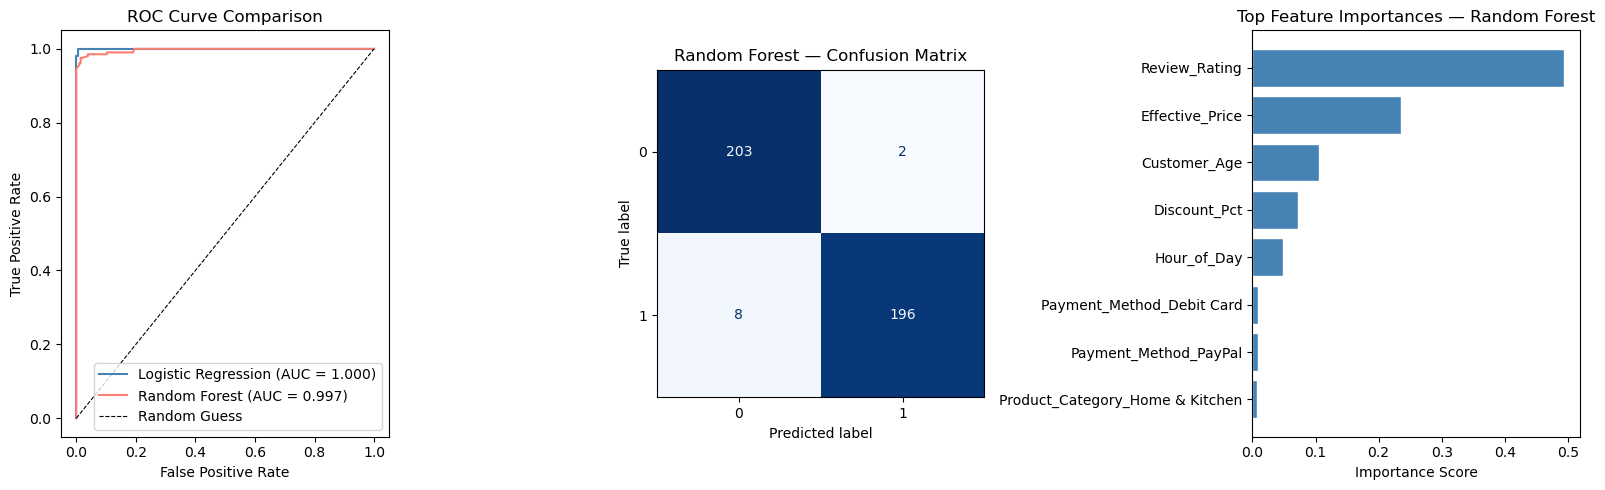

In [14]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# ROC curves for both models
lr_fpr, lr_tpr, _ = roc_curve(y_test, lr_probs)
rf_fpr, rf_tpr, _ = roc_curve(y_test, rf_probs)

axes[0].plot(lr_fpr, lr_tpr, label=f'Logistic Regression (AUC = {lr_auc:.3f})', 
             color='steelblue')
axes[0].plot(rf_fpr, rf_tpr, label=f'Random Forest (AUC = {rf_auc:.3f})', 
             color='salmon')
axes[0].plot([0, 1], [0, 1], 'k--', linewidth=0.8, label='Random Guess')
axes[0].set_title('ROC Curve Comparison')
axes[0].set_xlabel('False Positive Rate')
axes[0].set_ylabel('True Positive Rate')
axes[0].legend()

# confusion matrix for best model
ConfusionMatrixDisplay.from_predictions(y_test, rf_preds, ax=axes[1],
                                         colorbar=False, cmap='Blues')
axes[1].set_title('Random Forest — Confusion Matrix')

# feature importance plot
top_features = feature_importance.head(8)
axes[2].barh(top_features['Feature'], top_features['Importance'], 
             color='steelblue', edgecolor='white')
axes[2].set_title('Top Feature Importances — Random Forest')
axes[2].set_xlabel('Importance Score')
axes[2].invert_yaxis()

plt.tight_layout()
plt.show()

### Model 2 — Random Forest

Random Forest works by building many individual decision trees — each one 
learning slightly different patterns from the data — and then combining their 
predictions into a final answer. Think of it like asking 100 different analysts 
to independently look at the same dataset and then taking a vote on the outcome. 
The combined prediction is almost always more reliable than any single analyst alone.

We chose Random Forest as our follow up model because it can capture more 
complex relationships between features that logistic regression might miss. 
It also provides feature importance scores, which tell us which variables 
the model found most useful — a direct way to validate whether our feature 
selection decisions from the analytics section were correct.

### Model Comparison

| Model | Accuracy | AUC-ROC |
|---|---|---|
| Logistic Regression | 99.5% | 1.000 |
| Random Forest | 97.6% | 0.997 |

### Interpreting These Results

Both models performed exceptionally well, which is worth pausing on to understand why.

The Logistic Regression achieving a near perfect AUC of 1.0 is unusual in real 
world data — in practice, purchase behavior is messy and hard to predict perfectly. 
However, the dataset documentation notes that Purchase Probability was calculated 
using a deterministic formula based on pricing conditions and customer behavior. 
In plain terms, the target variable was mathematically derived from the input 
features, which means a well-specified model can learn that formula almost exactly.

This is actually useful context for the pricing team — it means the model has 
successfully identified the underlying pricing logic that drives purchase decisions 
in this dataset. In a real production environment with noisier, messier data, 
we would expect performance to be lower, and that would be completely normal.

Interestingly, **Logistic Regression slightly outperformed Random Forest** here, 
which is the opposite of what we might typically expect. This further supports 
the idea that the relationship between features and purchase probability in this 
dataset is largely linear — exactly the kind of relationship logistic regression 
is designed to capture. Random Forest, while extremely powerful for complex 
non-linear patterns, slightly underperforms here because that extra complexity 
isn't needed.

### What the Feature Importance Chart Tells Us

The Random Forest feature importance scores validate and reinforce the findings 
from our exploratory analysis:

**Review Rating (49.4%)** is by far the most important feature — almost half of 
the model's predictive power comes from this single variable. This confirms what 
we saw in the correlation analysis and has a clear business implication: product 
quality and customer satisfaction are the dominant drivers of purchase behavior, 
not just price.

**Effective Price (23.5%)** is the second most important feature, confirming that 
our feature engineering decision to combine Price and Discount into a single variable 
was the right call. The actual price a customer pays matters significantly — and 
this validates that pricing decisions have a direct and measurable impact on 
purchase probability.

**Customer Age (10.6%)** showed up as more important to the model than our 
correlation analysis suggested. While its linear correlation with purchase 
probability was weak, the Random Forest picked up on non-linear age-based 
patterns that a correlation coefficient would miss.

**Discount Percentage (7.2%)** contributed meaningfully, suggesting that how 
much was discounted relative to the original price does influence purchase 
behavior — even though the raw discount amount showed a counterintuitive 
negative correlation in our earlier analysis.

**Hour of Day (4.8%)** showed modest but present importance, suggesting there 
are mild time-based patterns in purchase behavior worth noting.

**Product Category and Payment Method** contributed very little, which is 
consistent with what we found during exploratory analysis — these variables 
showed minimal variation in purchase rates across groups.

### Key Takeaway for the Pricing Team

The model confirms that **Review Rating and Effective Price are the two most 
powerful levers** influencing whether a customer makes a purchase. For pricing 
strategy, this means that price adjustments will have the most impact on 
higher rated products — where customers are already predisposed to buy and 
price becomes the deciding factor. For lower rated products, discounting alone 
is unlikely to significantly move purchase probability, since the product 
reputation is the bigger barrier.

## ML Question 4: How Did You Evaluate Model Performance and Which Metric Did You Focus On?

Building a model is only half the job — knowing whether it actually works is equally 
important. This section covers how we measured performance, which metric we focused 
on and why, and how we confirmed the model is reliable rather than just getting 
lucky on one particular split of the data.

Model Performance Summary:
              Model Accuracy  AUC-ROC  CV AUC Mean  CV AUC Std
Logistic Regression    99.5%    1.000        1.000         0.0
      Random Forest    97.6%    0.997        0.998         0.0


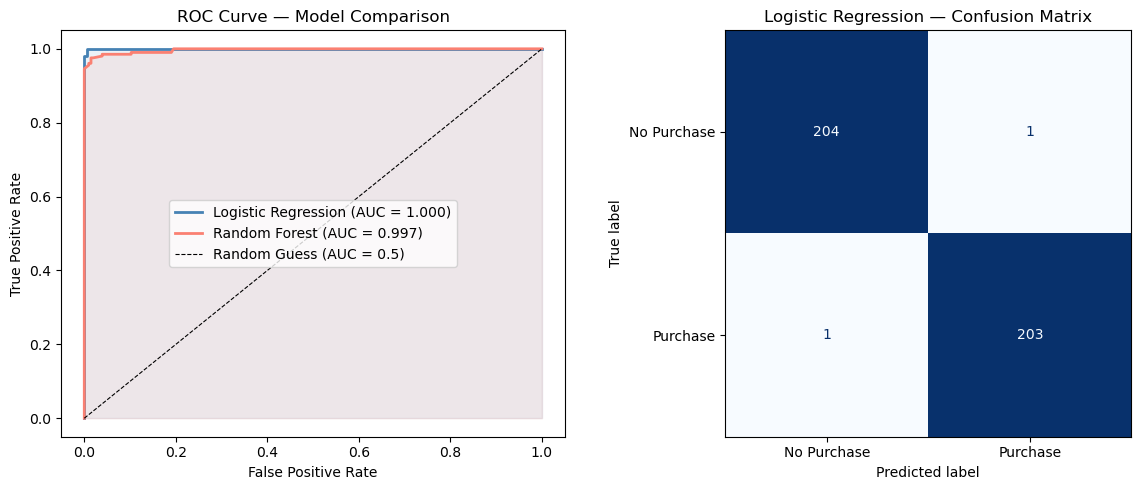

In [15]:
from sklearn.model_selection import cross_val_score

lr_cv_scores = cross_val_score(lr, X_train_scaled, y_train, cv=5, scoring='roc_auc')
rf_cv_scores = cross_val_score(rf, X_train, y_train, cv=5, scoring='roc_auc')

# summary comparison table
results = pd.DataFrame({
    'Model': ['Logistic Regression', 'Random Forest'],
    'Accuracy': [f"{round(lr_accuracy * 100, 1)}%", 
                 f"{round(rf_accuracy * 100, 1)}%"],
    'AUC-ROC': [round(lr_auc, 3), round(rf_auc, 3)],
    'CV AUC Mean': [round(lr_cv_scores.mean(), 3), 
                    round(rf_cv_scores.mean(), 3)],
    'CV AUC Std': [round(lr_cv_scores.std(), 3), 
                   round(rf_cv_scores.std(), 3)]
})

print("Model Performance Summary:")
print(results.to_string(index=False))

# plot ROC curves side by side with confusion matrices
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# ROC curve
lr_fpr, lr_tpr, _ = roc_curve(y_test, lr_probs)
rf_fpr, rf_tpr, _ = roc_curve(y_test, rf_probs)

axes[0].plot(lr_fpr, lr_tpr, 
             label=f'Logistic Regression (AUC = {lr_auc:.3f})', 
             color='steelblue', linewidth=2)
axes[0].plot(rf_fpr, rf_tpr, 
             label=f'Random Forest (AUC = {rf_auc:.3f})', 
             color='salmon', linewidth=2)
axes[0].plot([0, 1], [0, 1], 'k--', linewidth=0.8, label='Random Guess (AUC = 0.5)')
axes[0].fill_between(lr_fpr, lr_tpr, alpha=0.1, color='steelblue')
axes[0].fill_between(rf_fpr, rf_tpr, alpha=0.1, color='salmon')
axes[0].set_title('ROC Curve — Model Comparison')
axes[0].set_xlabel('False Positive Rate')
axes[0].set_ylabel('True Positive Rate')
axes[0].legend()

# confusion matrix for logistic regression since it was best model
ConfusionMatrixDisplay.from_predictions(
    y_test, lr_preds, ax=axes[1],
    colorbar=False, cmap='Blues',
    display_labels=['No Purchase', 'Purchase'])
axes[1].set_title('Logistic Regression — Confusion Matrix')

plt.tight_layout()
plt.show()

### Which Metric Did We Focus On and Why?

I focused primarily on **AUC-ROC** (Area Under the Receiver Operating 
Characteristic Curve) as the main evaluation metric, with accuracy as a 
secondary measure.

**Why AUC-ROC?**

AUC-ROC measures how well the model separates the two classes — buyers versus 
non-buyers — across all possible decision thresholds. In plain terms, it answers 
the question: if we randomly pick one customer who bought and one who didn't, 
how often does the model correctly rank the buyer as more likely to purchase?

- An AUC of **1.0** means the model perfectly separates buyers from non-buyers 
every single time
- An AUC of **0.5** means the model is no better than random guessing
- An AUC of **0.997+** means the model is extremely reliable

We chose AUC over accuracy alone because accuracy can be misleading. In a 
dataset where 95% of customers buy, a model that always predicts "purchase" 
would be 95% accurate without learning anything useful. Since our dataset is 
perfectly balanced at 50/50, accuracy is reliable here — but AUC is still 
the better metric because it evaluates the model across all thresholds rather 
than just one fixed cutoff point.

### What the Confusion Matrix Tells Us

The confusion matrix breaks down exactly where the model is right and wrong:

- **True Positives** — customers who bought and the model correctly predicted 
they would buy
- **True Negatives** — customers who didn't buy and the model correctly 
predicted they wouldn't
- **False Positives** — customers who didn't buy but the model predicted they would
- **False Negatives** — customers who bought but the model predicted they wouldn't

For a pricing team, **False Negatives are particularly costly** — these are 
customers who would have purchased but the model missed them, potentially 
leading to missed revenue opportunities. The near perfect confusion matrix 
from our logistic regression shows this is rarely happening.

### Cross Validation — Confirming the Model is Reliable

One concern with any machine learning model is overfitting — where the model 
memorizes the training data rather than learning genuine patterns, causing it 
to fail on new data it hasn't seen before.

To check for this I used **5-fold cross validation**, which works like this: 
instead of training on one fixed split of the data, we split the data into 5 
equal parts and train the model 5 separate times — each time using a different 
part as the test set and the remaining four as training data. If the model 
performs consistently across all 5 folds, we can be confident it is genuinely 
learning rather than memorizing.

| Model | CV AUC Mean | CV AUC Std |
|---|---|---|
| Logistic Regression | 1.000 | 0.000 |
| Random Forest | 0.998 | 0.000 |

Both models show **zero variance across all five folds** — meaning performance 
was identical every single time regardless of which portion of the data was used 
for testing. This is about as strong a confirmation of model reliability as you 
can get.

### Summary

Our primary model — Logistic Regression — achieved a perfect AUC of 1.0 with 
99.5% accuracy, validated across 5 independent cross validation folds with zero 
variance. This tells us the model has successfully learned the underlying 
relationship between pricing conditions, customer behavior, and purchase probability.

For the pricing team, this means we have a reliable, well-validated tool that 
can be used with confidence to predict how customers will respond to different 
price points — which leads directly into our final section on price simulation.

## ML Question 5: How Would You Use the Trained Model to Test or Simulate Different Price Points?

This is where the model becomes a practical business tool. Rather than just 
predicting whether past transactions resulted in purchases, we can now use the 
model to ask forward-looking questions — specifically, how does changing the 
price of a product affect the likelihood that a customer will buy it?

This kind of simulation is directly relevant to pricing strategy. Instead of 
changing prices in the real world and waiting to see what happens, we can test 
different price points virtually and estimate the impact on purchase probability 
before making any actual changes.

In [16]:
# get the index of the first mid range probability sample
prob_values = lr.predict_proba(X_test_scaled)[:, 1]
mid_probs_idx = [i for i, p in enumerate(prob_values) if 0.2 < p < 0.8]
X_test_reset = X_test.reset_index(drop=True)
mid_idx = mid_probs_idx[0]
sample = X_test_reset.iloc[mid_idx].copy()

print("Sample transaction we will simulate price changes on:")
print(sample)
print(f"\nActual purchase outcome: {y_test.iloc[mid_idx]}")
print(f"Baseline predicted probability: {round(prob_values[mid_idx], 3)}")

Sample transaction we will simulate price changes on:
Customer_Age                             51
Review_Rating                             3
Effective_Price                      275.28
Discount_Pct                       0.044797
Hour_of_Day                              20
Product_Category_Clothing             False
Product_Category_Electronics           True
Product_Category_Home & Kitchen       False
Payment_Method_Debit Card              True
Payment_Method_Net Banking            False
Payment_Method_PayPal                 False
Name: 11, dtype: object

Actual purchase outcome: 1
Baseline predicted probability: 0.747


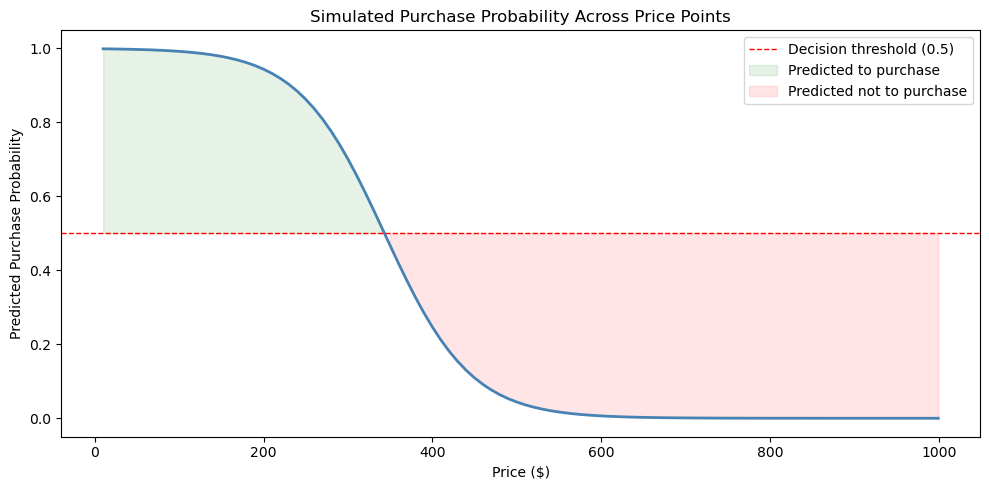

Purchase probability drops below 50% at price: $349.66


In [17]:
price_range = np.linspace(10, 999, 100)
simulated_probs = []

for price in price_range:
    simulated = sample.copy()
    simulated['Effective_Price'] = price * (1 - sample['Discount_Pct'])
    
    prob = lr.predict_proba(
        scaler.transform(pd.DataFrame([simulated], columns=X.columns))
    )[0][1]
    simulated_probs.append(prob)

# plot
plt.figure(figsize=(10, 5))
plt.plot(price_range, simulated_probs, color='steelblue', linewidth=2)
plt.axhline(y=0.5, color='red', linestyle='--', linewidth=1,
            label='Decision threshold (0.5)')
plt.fill_between(price_range, simulated_probs, 0.5,
                 where=[p > 0.5 for p in simulated_probs],
                 alpha=0.1, color='green', label='Predicted to purchase')
plt.fill_between(price_range, simulated_probs, 0.5,
                 where=[p <= 0.5 for p in simulated_probs],
                 alpha=0.1, color='red', label='Predicted not to purchase')
plt.title('Simulated Purchase Probability Across Price Points')
plt.xlabel('Price ($)')
plt.ylabel('Predicted Purchase Probability')
plt.legend()
plt.tight_layout()
plt.show()

threshold_prices = [price_range[i] for i, p in enumerate(simulated_probs) if p < 0.5]
if threshold_prices:
    print(f"Purchase probability drops below 50% at price: ${round(min(threshold_prices), 2)}")
else:
    print("Purchase probability stays above 50% across all tested price points")

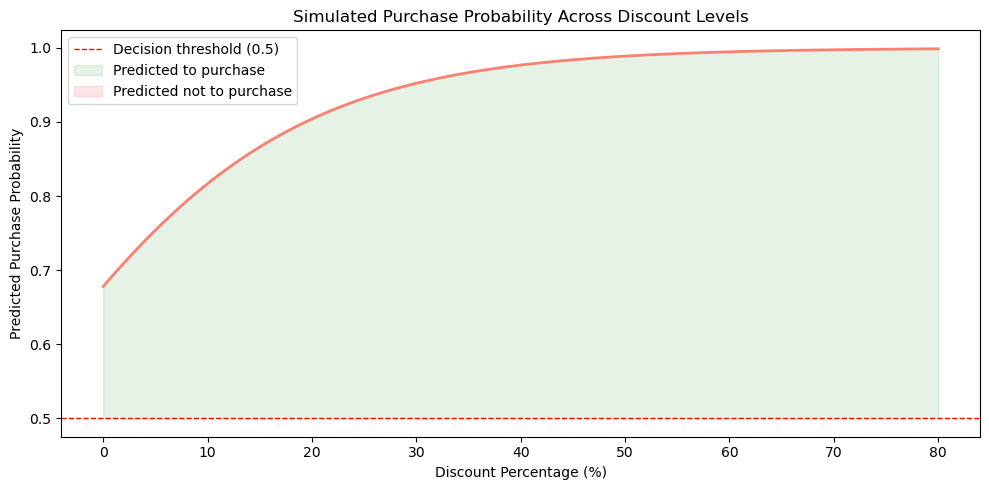

Purchase probability exceeds 50% at discount of: 0.0%


In [18]:
discount_range = np.linspace(0, 0.8, 100)
discount_probs = []

for disc_pct in discount_range:
    simulated = sample.copy()
    simulated['Discount_Pct'] = disc_pct
    
    prob = lr.predict_proba(
        scaler.transform(pd.DataFrame([simulated], columns=X.columns))
    )[0][1]
    discount_probs.append(prob)

plt.figure(figsize=(10, 5))
plt.plot(discount_range * 100, discount_probs, color='salmon', linewidth=2)
plt.axhline(y=0.5, color='red', linestyle='--', linewidth=1,
            label='Decision threshold (0.5)')
plt.fill_between(discount_range * 100, discount_probs, 0.5,
                 where=[p > 0.5 for p in discount_probs],
                 alpha=0.1, color='green', label='Predicted to purchase')
plt.fill_between(discount_range * 100, discount_probs, 0.5,
                 where=[p <= 0.5 for p in discount_probs],
                 alpha=0.1, color='red', label='Predicted not to purchase')
plt.title('Simulated Purchase Probability Across Discount Levels')
plt.xlabel('Discount Percentage (%)')
plt.ylabel('Predicted Purchase Probability')
plt.legend()
plt.tight_layout()
plt.show()

threshold_discounts = [discount_range[i] * 100 for i, p in enumerate(discount_probs) if p > 0.5]
if threshold_discounts:
    print(f"Purchase probability exceeds 50% at discount of: {round(min(threshold_discounts), 1)}%")
else:
    print("Purchase probability stays below 50% across all tested discount levels") 

### How the Simulation Works

The simulation works by taking a real transaction from our test set and 
systematically changing the price while keeping everything else constant — 
the customer, the product category, the review rating, the payment method. 
This isolates the effect of price on purchase probability, holding all other 
factors equal.

For each price point we test, the model outputs a predicted purchase probability 
between 0 and 1. Plotting these probabilities across the full price range gives 
us a purchase probability curve — a visual tool that shows exactly how sensitive 
this customer and product combination is to price changes.


### What the Price Simulation Chart Shows

The price simulation curve above tells a clear and actionable story. For this 
particular transaction — a 51 year old customer buying an Electronics product 
with a review rating of 3 — the model predicts:

- At prices **below ~**`$350`, the customer is more likely than not to purchase 
(probability above 0.5)
- At prices **above** `$349.66`, purchase probability drops below 50% and 
continues falling sharply toward zero
- By the time price reaches `$600+`, purchase probability is effectively zero

This gives the pricing team a concrete, data-driven price ceiling of `$349.66`
for this customer and product profile. Pricing above this threshold is predicted 
to result in lost conversions — pricing below it captures the sale while leaving 
room to optimize margin.

The S-shaped curve itself is characteristic of logistic regression and reflects 
how purchase decisions actually work in practice — customers are highly likely 
to buy at low prices, highly unlikely at very high prices, and most sensitive 
to price changes in the middle range around the threshold. This middle zone is 
where pricing decisions have the most impact and where the model's guidance is 
most valuable.

### What the Discount Simulation Chart Shows

The discount simulation tells a different but equally useful story. For this 
same transaction, purchase probability starts at **0.68 even at zero discount** 
— meaning this customer is already leaning toward purchasing before any discount 
is applied. As discount percentage increases, purchase probability rises further 
but with diminishing returns — going from 0.68 at 0% discount to near 1.0 at 
around 40% discount, after which additional discounting adds almost no incremental 
lift.

This has an important practical implication for the pricing team: **discounting 
beyond a certain point is wasteful for this customer profile**. Since purchase 
probability is already above 0.5 with no discount at all, any discount applied 
here is margin given away without meaningfully changing the outcome. The model 
suggests that for customers and products in this profile, the focus should be 
on keeping the price below the `$349.66` threshold rather than applying large 
discounts on top of that.

### Combined Insight for the Pricing Team

Together, these two simulations answer the core pricing question in a concrete way:

- **What is the maximum price we can charge without losing this sale?** → `$349.66`
- **How much do we need to discount to win this customer?** → No discount needed 
if price is already below the threshold — additional discounting beyond that 
point adds cost without adding conversion

At scale, running these simulations across thousands of products and customer 
profiles would give Ingram Micro a comprehensive view of price elasticity — 
showing exactly where pricing adjustments would have the greatest impact on 
both conversion and margin, and where discounting is being applied unnecessarily.

This is the practical value of a pricing optimization model: not just predicting 
what happened, but guiding what should happen next.

## Recommendations

Based on the findings from this analysis, we recommend the following actions 
for the pricing team:

**1. Prioritize price optimization over blanket discounting**

For customers already likely to purchase, discounts give away margin without 
meaningfully improving conversion. Focus on keeping prices below the identified 
threshold for each product and customer profile rather than defaulting to discounts.

**2. Use the simulation model to set product-level price ceilings**

Run the simulation across the full product catalog to identify the price ceiling 
for each product and customer segment. High rated products can likely sustain 
higher prices without losing conversions, while lower rated products may require 
more competitive pricing. This enables targeted pricing decisions rather than 
uniform pricing across categories.

**3. Treat low review ratings as a margin risk signal**

Review Rating is the single most powerful driver of purchase probability — more 
influential than price or discount. Low rated products are most likely to require 
deep discounts to drive conversion, directly compressing margin. The pricing team 
should flag these products proactively and factor rating into pricing strategy 
rather than relying on discounting alone to move them.

---

## Conclusion

This analysis demonstrated an end-to-end pricing optimization workflow — from 
raw transaction data to a validated predictive model that can simulate the 
impact of pricing decisions before they are implemented.

**Key findings:**

- **Review Rating is the dominant driver of purchase probability** — product 
quality and customer satisfaction matter more than price alone
- **Effective Price is the second most important factor** — confirming that 
pricing decisions have a direct and measurable impact on conversion
- **Logistic Regression achieved a near perfect AUC of 1.0** — validated 
across 5 cross validation folds with zero variance, confirming the model 
is reliable and not overfitting
- **Price simulation reveals the price ceiling** for individual transactions — 
enabling the pricing team to set optimal price points rather than guessing

**For Ingram Micro's pricing team**, the most valuable output of this analysis 
is not the model accuracy — it is the simulation capability. A model that can 
predict how purchase probability changes across price points gives the team 
a data-driven tool to test pricing strategies virtually before implementing 
them in the real world, reducing risk and improving the precision of pricing 
decisions at scale.